# Practical 8: Deterministic Modelling of a Simple Signaling Pathway Using ODEs


### Important note for students

**You do NOT need a mathematics background for this practical.**

We will learn the idea step by step. You do not need to understand calculus before starting.

We will use Python to answer a simple biological question:

> **If a signal enters a cell, how does the amount of an activated protein and a downstream cellular response change with time?**

We will first understand the biology, then the idea of a mathematical model, and finally let Python do the calculations for us.

---


---

### What we will learn

1. What a signaling pathway is.
2. What a deterministic model means.
3. What an ODE means in simple biological language.
4. How to install/import Python libraries.
5. How to write a very simple model in Python.
6. How SciPy solves the model.
7. How to make a graph.
8. How changing a biological parameter changes the response.

### Software

We will use:

- Python
- NumPy
- SciPy
- Matplotlib
- Jupyter Notebook

### Simple Signaling Pathway

```text
External or Internal Signal
            |
            v
     Inactive Protein
            |
       activation
            |
            v
     Activated Protein
            |
        activates
            |
            v
      Cellular Response

# Practical 8: Deterministic Modelling of a Simple Signaling Pathway Using ODEs

### Important note for students

**You do NOT need a mathematics background for this practical.**

We will learn the idea step by step. You do not need to understand calculus before starting.

We will use Python to answer a simple biological question:

> **If a signal enters a cell, how does the amount of an activated protein and a downstream cellular response change with time?**

We will first understand the biology, then the idea of a mathematical model, and finally let Python do the calculations for us.

---

### Simple Signaling Pathway

![Simple Signaling Pathway](/content/signaling_pathway.png)

**Figure 1.** A simplified representation of signal transduction: a signal activates an inactive protein, producing an activated protein that subsequently generates a downstream cellular response.

---

### What we will learn

1. What a signaling pathway is.
2. What a deterministic model means.
3. What an ODE means in simple biological language.
4. How to install/import Python libraries.
5. How to write a very simple model in Python.
6. How SciPy solves the model.
7. How to make a graph.
8. How changing a biological parameter changes the response.

### Software

We will use:

- Python
- NumPy
- SciPy
- Matplotlib
- Jupyter Notebook

# Part 2 — What does "dynamic" mean?

In biology, molecules do not usually stay at exactly the same concentration.

For example:

```text
Time = 0 min       → very little activated protein
Time = 5 min       → some activated protein
Time = 10 min      → more activated protein
Time = 20 min      → concentration may level off
```

So instead of asking only:

> "How much activated protein is present?"

we ask:

> **"How does the amount of activated protein change with time?"**

This is the central idea of today's practical.

A model that follows a biological quantity **over time** is called a **dynamic model**.


# Part 3 — What does "deterministic" mean?

The word **deterministic** sounds complicated, but the idea is simple.

A deterministic model gives the same result whenever we start with the same:

- starting conditions
- parameter values
- equations

For example:

```text
Same signal
    +
Same starting concentration
    +
Same parameter values
    =
Same predicted result
```

There is no random number being added to the model.

Later, you may learn about **stochastic models**, where random effects are included.

For today's practical:

> **Deterministic = predictable model based on defined rules.**


# Part 4 — What is an ODE?

ODE stands for:

**Ordinary Differential Equation**

Do not worry about the mathematical name.

For this practical, you can think of an ODE as:

> **A rule that tells Python how quickly a biological quantity changes with time.**

For example:

```text
Signal activates protein
        ↓
Activated protein increases

Protein is removed
        ↓
Activated protein decreases
```

So the model needs to calculate:

```text
increase − decrease
```

That gives us the **change in concentration over time**.

Python will perform the numerical calculations for us.


# Part 5 — Our simple biological model

We will use four rate parameters.

| Symbol | Meaning | Simple interpretation |
|---|---|---|
| S | Signal | Strength of the incoming signal |
| k1 | Activation rate | How strongly the signal activates the protein |
| k2 | Deactivation rate | How quickly activated protein is removed |
| k3 | Response rate | How strongly activated protein produces the response |
| k4 | Response removal rate | How quickly the response disappears |

Our pathway is:

```text
             k1
Signal ─────────────> Activated Protein
                         |
                         | k3
                         v
                    Cellular Response

Activated Protein ──k2──> removed
Cellular Response  ──k4──> removed
```

We will use simple numbers for all of these parameters.


# Part 6 — The equations (only after understanding the biology)

Now we can write the biological rules mathematically.

For activated protein:

**change in activated protein = activation − removal**

For cellular response:

**change in response = production − removal**

The mathematical form is:

$$
\frac{dA}{dt} = k_1S - k_2A
$$

and

$$
\frac{dR}{dt} = k_3A - k_4R
$$

### You do NOT need to solve these equations by hand.

That is the job of the computer.

For this practical, understand only this:

```text
dA/dt  → how quickly A changes with time

dR/dt  → how quickly R changes with time
```

Python + SciPy will calculate these values repeatedly to produce the time-course graph.


# Part 7 — Start Python

If you are using Jupyter Notebook or JupyterLab, create a new Python notebook.

Before starting, check that Python is available.

The following is a **Shell/Terminal command**, not Python.

### Shell command

Run this in your terminal if you need to check Python:

```bash
python --version
```

If your system uses `python3`, use:

```bash
python3 --version
```

You should see a Python version such as:

```text
Python 3.x.x
```


# Part 8 — Install the required libraries

If NumPy, SciPy, or Matplotlib are not installed, install them from a **terminal/shell**.

### Shell command

```bash
pip install numpy scipy matplotlib jupyter
```

If your computer uses `pip3`:

```bash
pip3 install numpy scipy matplotlib jupyter
```

### Important

You normally run installation commands **once**.

You do not need to run `pip install` every time you execute a Python cell.

If you are using Google Colab, the libraries are generally already available.


# Part 9 — Import the libraries

Now we move from the **Shell** to a **Python code cell**.

We need three libraries:

- NumPy → creates numerical arrays and time points
- SciPy → solves the ODE
- Matplotlib → creates graphs


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

print("All libraries imported successfully.")

All libraries imported successfully.


### What did we just do?

This line:

```python
import numpy as np
```

means:

> Bring NumPy into Python and call it `np`.

This line:

```python
import matplotlib.pyplot as plt
```

means:

> Bring the graphing part of Matplotlib into Python and call it `plt`.

This line:

```python
from scipy.integrate import solve_ivp
```

means:

> Bring SciPy's ODE-solving function into our notebook.

You do not need to memorize these commands immediately.


# Part 10 — Define the biological parameters

Now we give numerical values to our model.

We will start with:

```text
Signal concentration (S) = 1.0

k1 = 0.5
k2 = 0.2
k3 = 0.4
k4 = 0.1
```

Think of these as the **rules of the biological system**.

Later, we will change them and see what happens.


In [ ]:
# Signal strength
S = 1.0

# Rate parameters
k1 = 0.5   # protein activation
k2 = 0.2   # protein deactivation
k3 = 0.4   # response production
k4 = 0.1   # response removal

print("Signal =", S)
print("k1 =", k1)
print("k2 =", k2)
print("k3 =", k3)
print("k4 =", k4)

Signal = 1.0
k1 = 0.5
k2 = 0.2
k3 = 0.4
k4 = 0.1


# Part 11 — Define the starting concentrations

At the beginning of our experiment, assume:

```text
Activated protein = 0
Cellular response = 0
```

This means the pathway starts in an inactive state.

We will call these starting values **initial conditions**.

In Python:


In [ ]:
# Starting concentration of activated protein
A_initial = 0.0

# Starting concentration of cellular response
R_initial = 0.0

# Put both starting values into one list
initial_conditions = [A_initial, R_initial]

print("Initial conditions =", initial_conditions)

Initial conditions = [0.0, 0.0]


# Part 12 — Define the time period

We want to observe what happens from:

```text
0 to 50 time units
```

We also tell Python to calculate many points between 0 and 50.

The more points we use, the smoother our graph will look.


In [ ]:
# Start and end of the simulation
time_start = 0
time_end = 50

# Create 500 time points between 0 and 50
time_points = np.linspace(time_start, time_end, 500)

print("Simulation starts at:", time_start)
print("Simulation ends at:", time_end)
print("Number of time points:", len(time_points))

Simulation starts at: 0
Simulation ends at: 50
Number of time points: 500


# Part 13 — Write the ODE model

This is the most important Python function in the practical.

Do not try to memorize it.

Read it together with the biological rules:

```text
Activated protein:
increase from signal − decrease from removal

Response:
increase from activated protein − decrease from removal
```


In [ ]:
def signaling_model(t, y):

    # y contains the current concentrations
    A, R = y

    # Change in activated protein
    dA_dt = k1 * S - k2 * A

    # Change in cellular response
    dR_dt = k3 * A - k4 * R

    # Give both changes back to SciPy
    return [dA_dt, dR_dt]

## Understanding the function

### Line 1

```python
def signaling_model(t, y):
```

This creates a Python function called `signaling_model`.

---

### Line 2

```python
A, R = y
```

The computer stores the current concentrations in `y`.

We separate them into:

```text
A = activated protein
R = cellular response
```

---

### Line 3

```python
dA_dt = k1 * S - k2 * A
```

This follows our biological rule:

```text
activation − removal
```

---

### Line 4

```python
dR_dt = k3 * A - k4 * R
```

This follows:

```text
response production − response removal
```

---

### Final line

```python
return [dA_dt, dR_dt]
```

We give the two calculated changes back to SciPy.


# Part 14 — Solve the model

Now we ask SciPy to solve the system.

The function we use is:

```python
solve_ivp()
```

You can think of SciPy as doing this repeatedly:

```text
Start
  ↓
Calculate change
  ↓
Move a small step forward in time
  ↓
Calculate new change
  ↓
Move forward again
  ↓
Repeat many times
  ↓
Produce the complete time course
```

This is why we do not need to manually solve the equations.


In [ ]:
solution = solve_ivp(
    signaling_model,
    (time_start, time_end),
    initial_conditions,
    t_eval=time_points
)

print("Simulation completed successfully.")

Simulation completed successfully.


# Part 15 — Look at the numerical results

The solver has produced values for:

- time
- activated protein
- cellular response

Let's inspect the first few values.


In [ ]:
print("First 5 time points:")
print(solution.t[:5])

print("\nFirst 5 activated protein values:")
print(solution.y[0][:5])

print("\nFirst 5 response values:")
print(solution.y[1][:5])

First 5 time points:
[0.        0.1002004 0.2004008 0.3006012 0.4008016]

First 5 activated protein values:
[0.         0.04960153 0.09821898 0.14587187 0.19257929]

First 5 response values:
[0.         0.00099401 0.00393635 0.00876871 0.01543439]


### Understanding `solution.y`

The solver stores the results in an array.

We use:

```python
solution.y[0]
```

for the activated protein.

We use:

```python
solution.y[1]
```

for the cellular response.

And:

```python
solution.t
```

contains the time values.


# Part 16 — Make the first graph

Now we will visualize the model.

A graph is much easier to interpret than a long list of numbers.

We will plot:

- Activated protein against time
- Cellular response against time


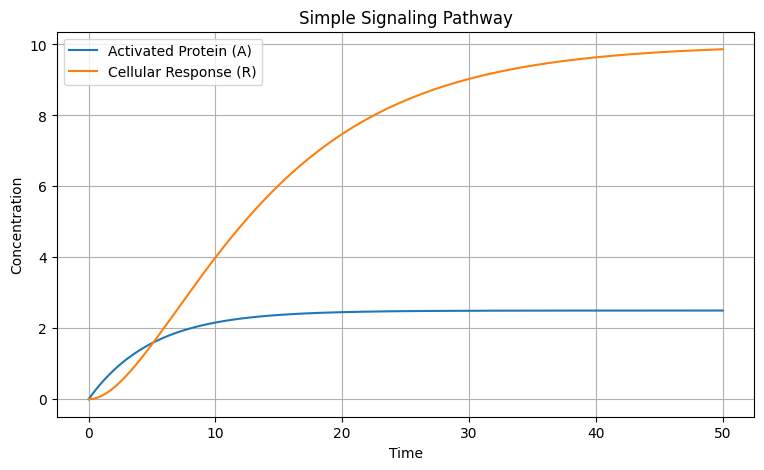

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    solution.t,
    solution.y[0],
    label="Activated Protein (A)"
)

plt.plot(
    solution.t,
    solution.y[1],
    label="Cellular Response (R)"
)

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Simple Signaling Pathway")
plt.legend()
plt.grid(True)

plt.show()

# Part 17 — How to read the graph

Look carefully at the graph.

Ask yourself:

### Question 1
Does the activated protein increase after the signal is introduced?

### Question 2
Does the cellular response increase?

### Question 3
Which one starts changing first?

### Question 4
Does the concentration continue increasing forever?

### Question 5
Does the system eventually approach a relatively stable level?

The important biological idea is:

```text
Signal
  ↓
Activated protein increases
  ↓
Cellular response increases
  ↓
Production and removal become balanced
  ↓
System approaches a steady state
```


# Part 18 — What is a steady state?

A **steady state** does not necessarily mean that molecules have stopped existing.

It means that the amount is changing very little because:

```text
production ≈ removal
```

For example:

```text
100 molecules produced
100 molecules removed
----------------------
Net change ≈ 0
```

So the measured concentration can remain approximately constant.

This is an important concept in biological systems.


# Part 19 — A simple experiment: increase the signal

Now we will perform a computational experiment.

First, our signal was:

```text
S = 1.0
```

What happens if the signal becomes stronger?

We will compare:

```text
S = 0.5
S = 1.0
S = 2.0
```

This is similar to asking:

> How does the strength of an external signal affect the cellular response?


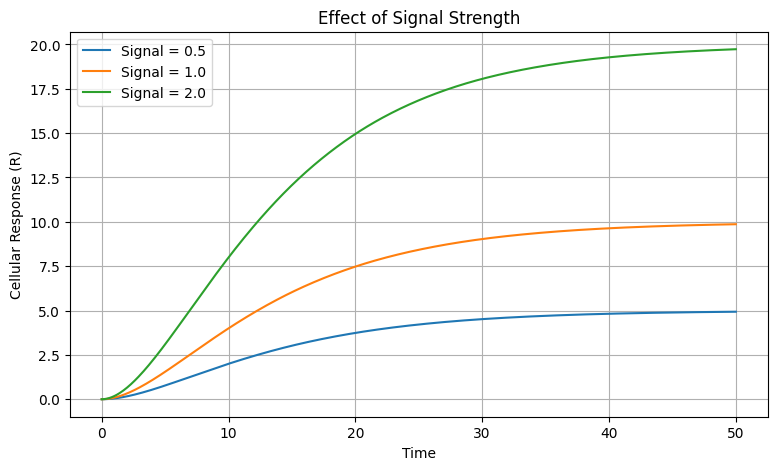

In [ ]:
# Signal strengths we want to test
signal_values = [0.5, 1.0, 2.0]

plt.figure(figsize=(9, 5))

for signal in signal_values:

    # Change the signal
    S = signal

    # Run the simulation
    result = solve_ivp(
        signaling_model,
        (time_start, time_end),
        initial_conditions,
        t_eval=time_points
    )

    # Plot cellular response
    plt.plot(
        result.t,
        result.y[1],
        label=f"Signal = {signal}"
    )

plt.xlabel("Time")
plt.ylabel("Cellular Response (R)")
plt.title("Effect of Signal Strength")
plt.legend()
plt.grid(True)

plt.show()

# Restore the original value
S = 1.0

# Part 20 — Interpret the signal experiment

You should now have several curves on one graph.

Think about what you see.

Generally:

```text
Higher signal
     ↓
More protein activation
     ↓
Stronger downstream response
```

This is an example of using a mathematical model to explore a biological hypothesis.

We changed one input:

```text
Signal strength
```

and observed its effect on:

```text
Cellular response
```


# Part 21 — Second experiment: faster protein deactivation

Now we will change `k2`.

Remember:

```text
k2 = protein deactivation/removal rate
```

First:

```text
k2 = 0.2
```

Now we will test:

```text
k2 = 0.5
```

Biological question:

> What happens if activated protein is removed more quickly?


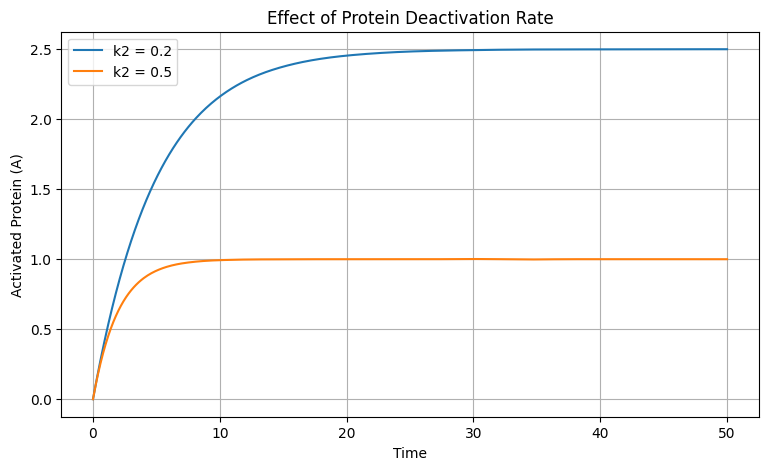

In [ ]:
# Keep the original signal
S = 1.0

# Original deactivation rate
k2_original = 0.2

# Faster deactivation rate
k2_faster = 0.5

# Run the original model
k2 = k2_original

original = solve_ivp(
    signaling_model,
    (time_start, time_end),
    initial_conditions,
    t_eval=time_points
)

# Run the faster deactivation model
k2 = k2_faster

faster_removal = solve_ivp(
    signaling_model,
    (time_start, time_end),
    initial_conditions,
    t_eval=time_points
)

# Plot comparison
plt.figure(figsize=(9, 5))

plt.plot(
    original.t,
    original.y[0],
    label="k2 = 0.2"
)

plt.plot(
    faster_removal.t,
    faster_removal.y[0],
    label="k2 = 0.5"
)

plt.xlabel("Time")
plt.ylabel("Activated Protein (A)")
plt.title("Effect of Protein Deactivation Rate")
plt.legend()
plt.grid(True)

plt.show()

# Restore original value
k2 = 0.2

# Part 22 — What did we learn from changing k2?

If activated protein is removed faster:

```text
Faster removal
      ↓
Less activated protein remains
      ↓
Downstream signaling can be reduced
```

This shows why model parameters are biologically meaningful.

A parameter is not just a random number.

It can represent a biological process such as:

- activation
- degradation
- deactivation
- production
- removal


# Part 23 — Optional: calculate the expected steady state

This section introduces a little more mathematics, but you still do **not** need to calculate it manually.

For activated protein, the steady state is approximately:

```text
activation = removal
```

The corresponding value is:

$$
A_{ss} = \frac{k_1S}{k_2}
$$

For the response:

$$
R_{ss} = \frac{k_3A_{ss}}{k_4}
$$

Python can calculate these values for us.


In [ ]:
# Calculate theoretical steady-state values

A_steady = (k1 * S) / k2
R_steady = (k3 * A_steady) / k4

print("Expected steady-state activated protein:", A_steady)
print("Expected steady-state response:", R_steady)

Expected steady-state activated protein: 2.5
Expected steady-state response: 10.0


# Part 24 — Beginner exercise

Complete these experiments one at a time.

## Exercise 1 — Change the signal

Change:

```python
S = 1.0
```

to:

```python
S = 2.0
```

Run the model again.

**Question:** Does the final response increase or decrease?

---

## Exercise 2 — Change protein removal

Change:

```python
k2 = 0.2
```

to:

```python
k2 = 0.5
```

Run the model again.

**Question:** What happens to activated protein?

---

## Exercise 3 — Change response production

Change:

```python
k3 = 0.4
```

to:

```python
k3 = 0.8
```

**Question:** What happens to the cellular response?

---

## Exercise 4 — Change response removal

Change:

```python
k4 = 0.1
```

to:

```python
k4 = 0.2
```

**Question:** Does the final response become higher or lower?


# Part 25 — Mini project

Create a graph comparing the cellular response for three signal strengths:

```text
S = 0.5
S = 1.0
S = 2.0
```

Your graph should contain:

- Time on the x-axis
- Cellular response on the y-axis
- A separate curve for each signal strength
- A legend
- A suitable title

### Biological question

> **How does signal strength influence the magnitude of the cellular response?**

Write 2–3 sentences explaining your observation.


# Part 26 — Troubleshooting

## Error: `ModuleNotFoundError`

For example:

```text
ModuleNotFoundError: No module named 'scipy'
```

Run this in the terminal:

```bash
pip install scipy
```

---

## Error: `NameError`

For example:

```text
NameError: name 'S' is not defined
```

This usually means a previous code cell has not been run.

### Solution

Run the notebook cells from the beginning in order.

In Jupyter:

```text
Kernel → Restart Kernel and Run All Cells
```

---

## The graph does not appear

Make sure the last line of your plotting cell is:

```python
plt.show()
```

---

## The results look different

Check whether you changed any of these:

```text
S
k1
k2
k3
k4
```

The output depends on these parameter values.


# Part 27 — Final understanding check

Before finishing, make sure you can answer these questions.

### Biology

**1. What is the role of the signal?**

---

**2. What is activated protein (A)?**

---

**3. What does the cellular response (R) represent?**

---

### Modelling

**4. What does deterministic mean?**

---

**5. What does an ODE tell us in this practical?**

---

**6. Why do we need initial conditions?**

---

### Python

**7. What does NumPy do?**

---

**8. What does SciPy do?**

---

**9. What does Matplotlib do?**

---

**10. What does `solve_ivp()` do?**

---

### Interpretation

**11. What happens when signal strength increases?**

---

**12. What happens when protein deactivation becomes faster?**

---

**13. What does steady state mean?**


# Part 28 — Take-home message

The entire practical can be summarized as:

```text
BIOLOGICAL SYSTEM
       ↓
Define biological processes
       ↓
Convert processes into simple rules
       ↓
Write ODE model
       ↓
Python + SciPy
       ↓
Numerical simulation
       ↓
Plot concentration vs time
       ↓
Interpret biological behavior
```

### The key idea

You do **not** need to solve differential equations manually.

Your job is to:

1. Understand the biological process.
2. Understand what each parameter represents.
3. Provide the model to Python.
4. Let SciPy perform the numerical calculation.
5. Interpret the resulting biological behavior.

This is the foundation of **computational systems biology and mathematical modelling of biological pathways**.
